# [Deep Agents - Long-term memory](https://docs.langchain.com/oss/python/deepagents/long-term-memory)


- Deep Agents는 메모리를 오프로드하기 위한 로컬 파일시스템을 제공합니다. 기본적으로 이 파일시스템은 에이전트 상태에 저장되며 **단일 스레드에만 일시적**입니다. 즉, 대화가 끝나면 파일이 손실됩니다.

- **Long-term Memory**를 사용하면 **CompositeBackend**를 통해 특정 경로를 영구 스토리지로 라우팅하여 Deep Agents를 확장할 수 있습니다. 이를 통해 일부 파일은 스레드 간에 유지되고 다른 파일은 일시적으로 유지되는 하이브리드 스토리지가 가능합니다.


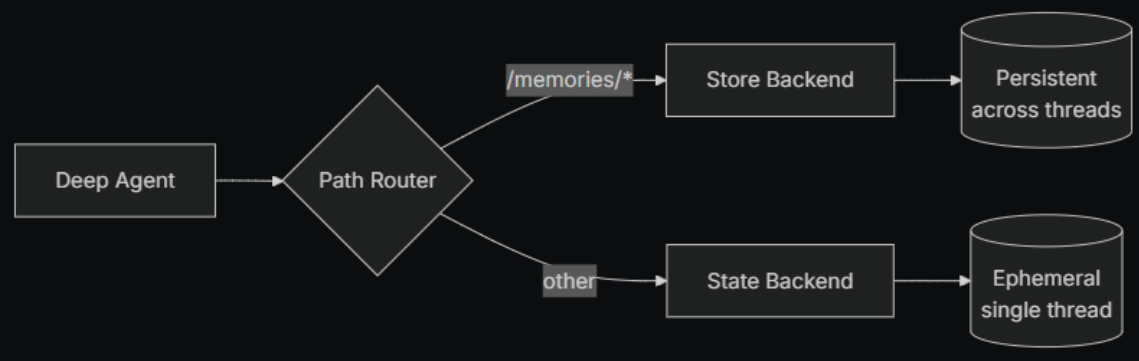

## 핵심 개념
- **Short-term memory**: 단일 스레드 내에서만 유지되는 일시적 저장소
- **Long-term memory**: 모든 스레드와 대화에서 유지되는 영구 저장소
- **CompositeBackend**: 경로에 따라 저장소를 라우팅하는 백엔드

## Built-in Backends 비교

| Backend | 저장 위치 | 지속성 | 사용 사례 |
|---------|----------|--------|-----------|
| **StateBackend** (기본) | LangGraph State | 단일 스레드 내에서만 유지 | 임시 작업, 스크래치 패드 |
| **FilesystemBackend** | 로컬 디스크 | 영구 저장 | 로컬 프로젝트, CI 샌드박스 |
| **StoreBackend** | LangGraph Store | 여러 스레드 간 공유 | 장기 메모리, 크로스 스레드 데이터 |
| **CompositeBackend** | 여러 백엔드 조합 | 경로별로 다름 | 복잡한 요구사항 (임시+영구 혼합) |


## CompositeBackend

CompositeBackend를 사용하면 Deep Agents는 **여러 개의 별도 파일시스템**을 유지합니다:

### Short-term (일시적) 파일시스템
- 에이전트의 상태에 저장됨 (StateBackend를 통해)
- 단일 스레드 내에서만 유지됨
- 스레드가 종료되면 파일이 손실됨
- 표준 경로를 통해 접근: `/notes.txt`, `/workspace/draft.md`

### Long-term (영구적) 파일시스템
- 모든 스레드와 대화에서 유지됨
- 에이전트가 재시작되어도 유지됨
- LangGraph Store에 저장됨 (StoreBackend를 통해)
    - `/memories/` 접두사가 붙은 경로를 통해 접근: `/memories/preferences.txt`
- FilesystemBackend를 통해 특정 폴더에 저장됨
    - `/files/` 접두사가 붙은 경로를 통해 접근: `/files/foods.json`

### 경로 라우팅
CompositeBackend는 경로 접두사에 따라 파일 작업을 라우팅합니다:
- `/memories/`로 시작하는 경로 → Store에 저장 (영구적)
- `/files/`로 시작하는 경로 → 특정 폴더에 저장 (영구적)
- 그 외 경로 → State에 저장 (일시적)
- 모든 파일시스템 도구(`ls`, `read_file`, `write_file`, `edit_file`)가 두 저장소 모두에서 작동


## 1. Setup


### 환경 변수 설정
- [OpenAI API Key](https://platform.openai.com/api-keys)
- [LangSmith API Key](https://smith.langchain.com/)


In [1]:
from dotenv import load_dotenv

# 환경 변수 로드
load_dotenv()

True

### LLM 정의 

In [2]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gpt-5-nano",
    reasoning_effort="high",        # 논리성 강화
)


### Short-term memory

> Checkpointer - Redis

#### Redis 시작하기

터미널에서 다음 명령어를 실행하세요:

```bash
cd redis
docker-compose up -d
```

Redis가 정상적으로 실행되었는지 확인:

```bash
docker ps
```

#### Redis Client

In [3]:
from common.redis import get_redis_client

redis_client = get_redis_client()

RedisJSON 모듈 확인 완료!


#### [RedisInsight 접속](http://localhost:8001/) 

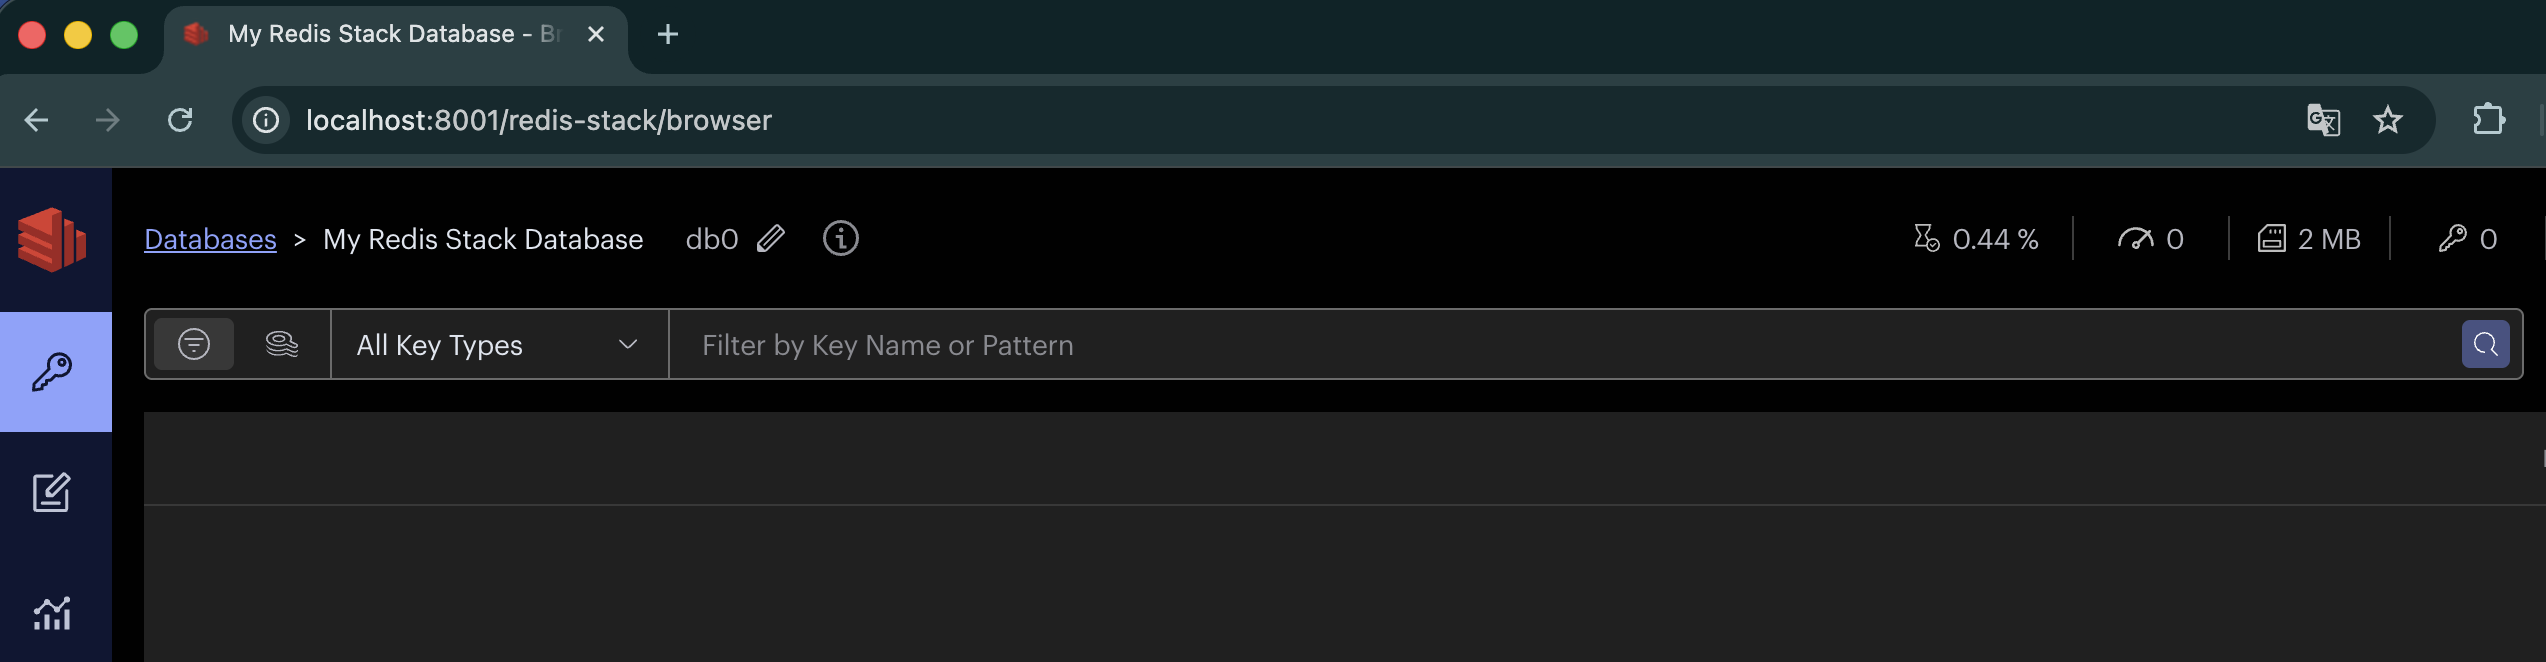

#### Checkpointer 정의 

In [4]:
from langgraph.checkpoint.redis import RedisSaver

# 3. Checkpointer 주입
checkpointer = RedisSaver(redis_client=redis_client)

# 처음 실행 시 인덱스가 생성될 때까지 아주 짧은 시간이 걸릴 수 있습니다.
try:
    # 내부적으로 인덱스를 생성하도록 유도
    checkpointer.setup() 
    print("체크포인트 인덱스 설정 완료")
except Exception as e:
    print(f"인덱스 설정 중 참고사항: {e}")

체크포인트 인덱스 설정 완료


### Long-term memory

> Store - PostgreSQL

#### PostgreSQL 시작하기

터미널에서 다음 명령어를 실행하세요:

```bash
cd postgresql
docker-compose up -d
```

정상적으로 실행되었는지 확인:

```bash
docker ps
```

#### PostgreDB

In [5]:
# PostgreSQL 연결 설정
DB_CONFIG = {
    "host": "localhost",
    "port": 5432,
    "database": "deepagent_db",
    "user": "admin",
    "password": "admin123"  # 실제 운영에서는 환경변수로 관리!
}

In [6]:
from common.postgresql import PostgreDB

# 싱글톤 패턴 동작 확인
print("\n=== 싱글톤 패턴 동작 확인 ===")
conn1 = PostgreDB(DB_CONFIG).get_conn()
conn2 = PostgreDB(DB_CONFIG).get_conn()

print(f"\n첫 번째 연결: {conn1}")
print(f"두 번째 연결: {conn2}")
print(f"같은 연결인가? {conn1 is conn2}")  # True여야 함
print("\n✓ 싱글톤 패턴 적용 완료! 동일한 연결을 재사용합니다.")


=== 싱글톤 패턴 동작 확인 ===

첫 번째 연결: <psycopg.Connection [IDLE] (host=localhost user=admin database=deepagent_db) at 0x111b40d70>
두 번째 연결: <psycopg.Connection [IDLE] (host=localhost user=admin database=deepagent_db) at 0x111b40d70>
같은 연결인가? True

✓ 싱글톤 패턴 적용 완료! 동일한 연결을 재사용합니다.


#### PostgreSQLStore

In [7]:
from langgraph.store.postgres import PostgresStore

# PostgreSQLStore 생성
postgre_store = PostgresStore(
    conn=PostgreDB(DB_CONFIG).get_conn()
)
postgre_store.setup() # 필요한 테이블 자동 생성

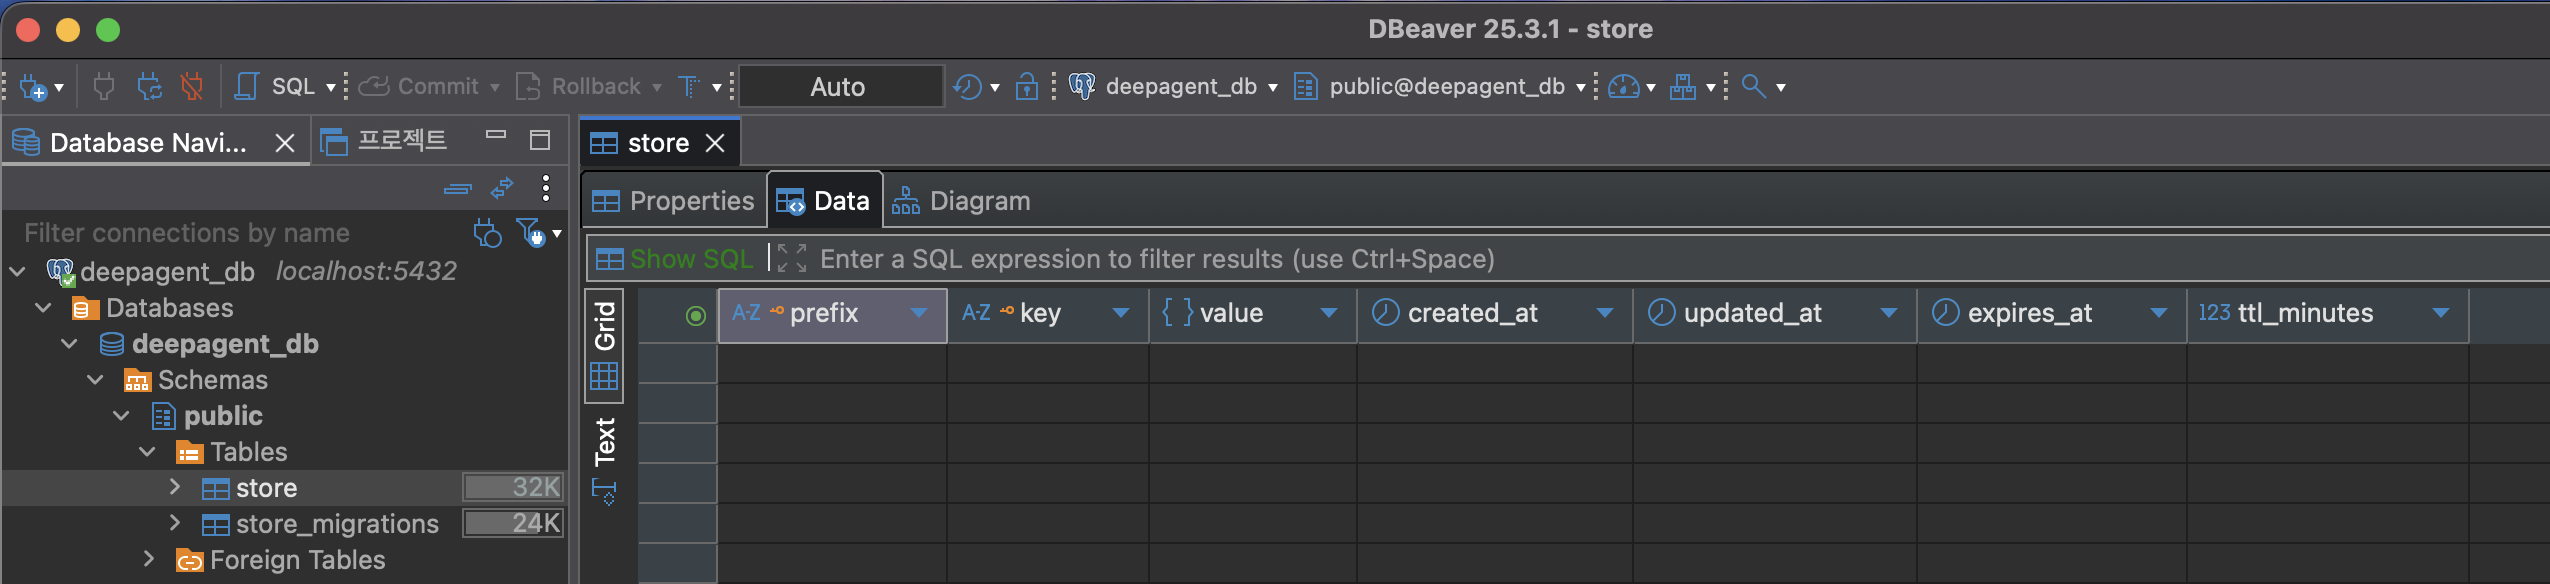

### FilessystemBackend용 폴더 생성

In [8]:
import os
from pathlib import Path

files_dir = Path("./files").resolve()

# exist_ok=True → 폴더가 이미 있어도 에러 안냄
os.makedirs(files_dir, exist_ok=True)

print("폴더 생성 완료:", files_dir)

폴더 생성 완료: /Users/gyoungwon-cho/dev/github/Inflearn/multi agents/3. DeepAgents/files


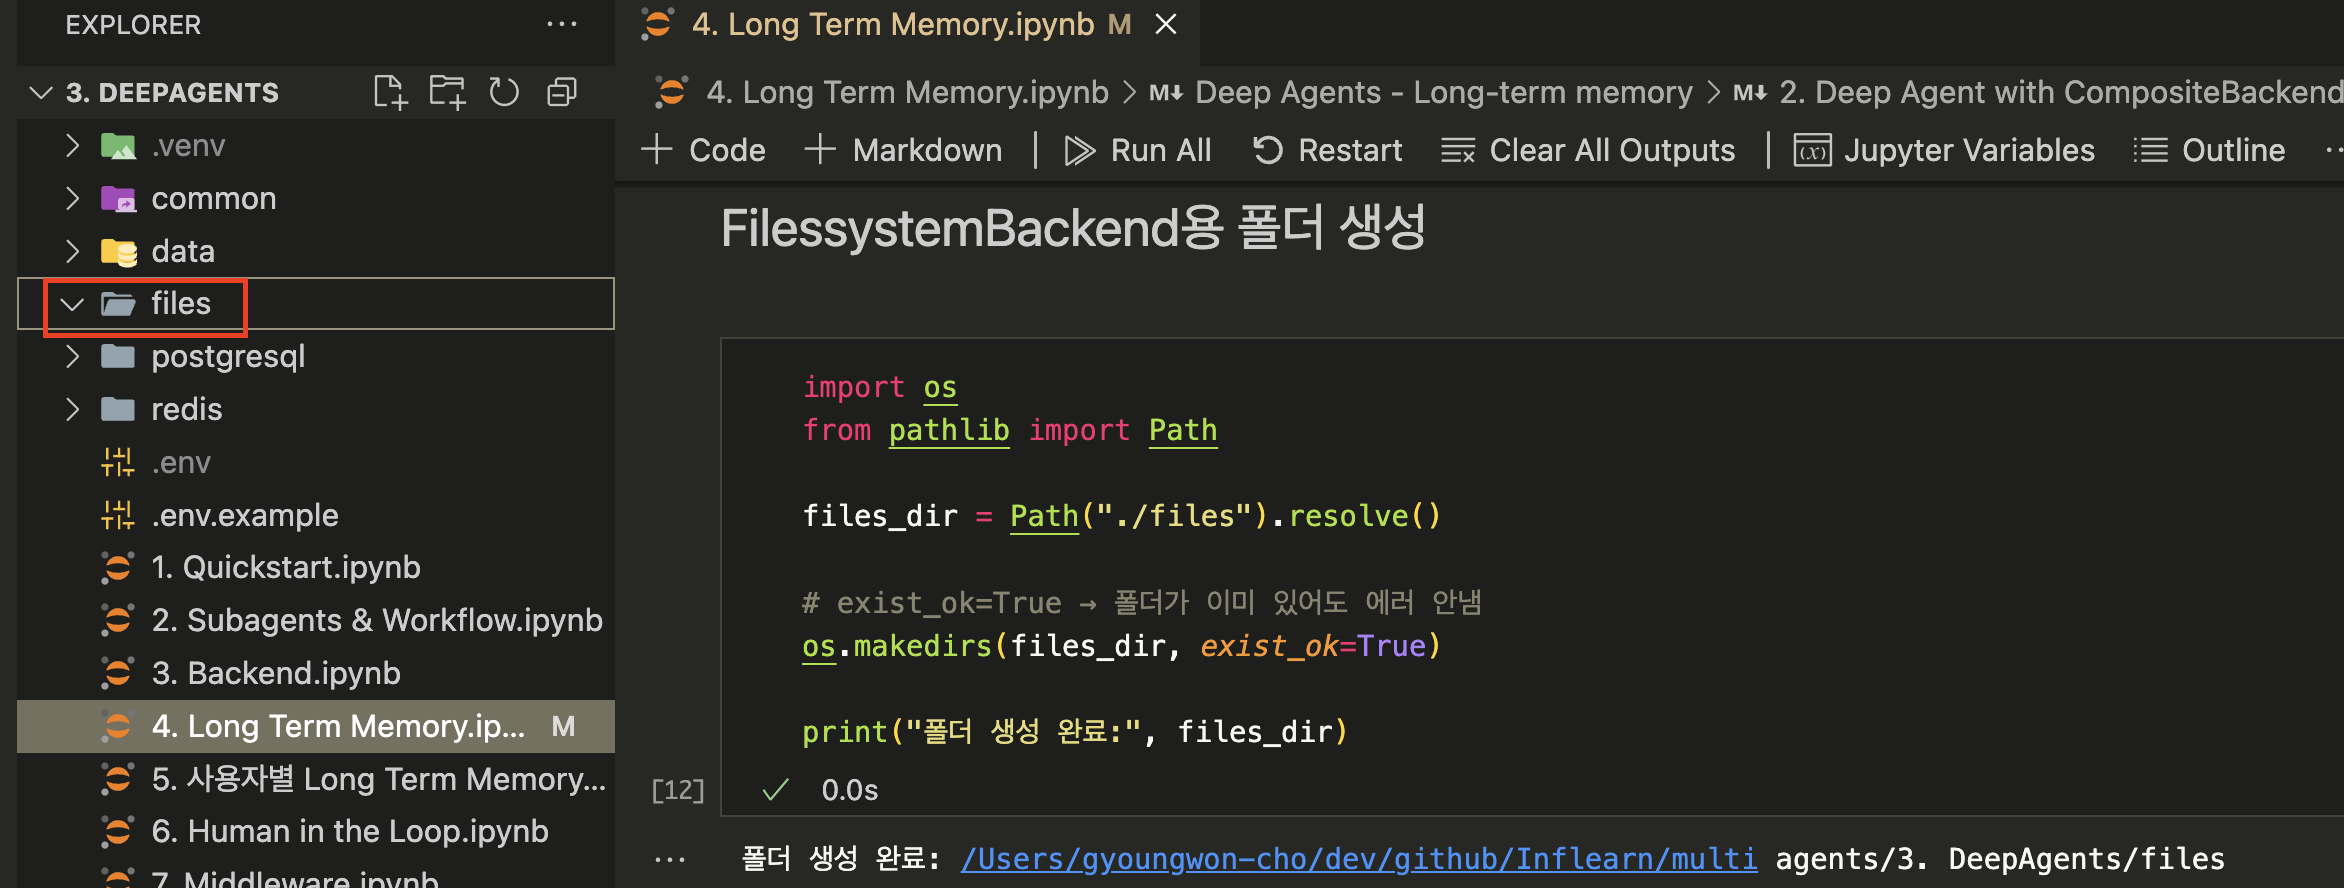

## 2. Deep Agent with CompositeBackend


### CompositeBackend

> Long-term memory를 위한 백엔드 설정

In [9]:
from deepagents.backends import CompositeBackend, StateBackend, StoreBackend, FilesystemBackend

# Long-term memory를 위한 백엔드 설정
def make_backend(runtime):
    return CompositeBackend(
        # 경로가 지정되지 않은 일반적인 상태값들은 StateBackend로 갑니다. 
        # 이 백엔드는 내부적으로 checkpointer를 사용하여 데이터를 기록합니다. 
        # 따라서 일시적 데이터는 checkpointer에 저장됩니다.
        default=StateBackend(runtime),  # 일시적 저장소 (Ephemeral storage)
        routes={
            "/memories/": StoreBackend(runtime),  # 영구 저장소 (Persistent storage)
            "/files/": FilesystemBackend(
                root_dir=files_dir, virtual_mode=True)   # 파일 저장소 (file storage)
        }
    )

### Deep Agent

In [10]:
from deepagents import create_deep_agent

# Deep Agent 생성
agent = create_deep_agent(
   model=llm,
   checkpointer=checkpointer,
   store=postgre_store,  # StoreBackend에 필요
   backend=make_backend,
   system_prompt="""
당신은 DeepAgent이며, 여러 종류의 저장소 Backend를 사용할 수 있습니다.
아래 규칙에 따라 데이터를 올바른 저장 경로에 저장해야 합니다.

[저장 규칙]

1. "/memories/" 경로는 영구 저장을 위한 공간입니다.
   - 사용자가 "기억해줘" 등의 요청을 하면 적절한 하위 폴더에 저장합니다.
   - 중요한 사용자 정보, 장기적으로 필요할 데이터, 에이전트 상태 등을 저장합니다.
   - StoreBackend를 통해 관리됩니다.
   - 중요한 정보는 반드시 이 경로를 사용해야 합니다.

2. "/files/" 경로는 파일 기반 저장을 위한 공간입니다.
   - 사용자가 "저장해줘" 등의 요청을 하면 적절한 하위 폴더에 저장합니다.
   - 문서, 분석 결과, 대용량 텍스트, 이미지/바이너리 데이터 등을 저장합니다.
   - FileSystemBackend를 통해 로컬 파일 시스템에 저장됩니다.

3. 기본(default) Backend는 임시적인 상태 저장용입니다.
   - 대화 흐름 중 일시적으로 필요한 내부 상태만 저장합니다.
   - StateBackend를 통해 관리됩니다.
   - 이곳에는 중요한 정보를 절대 저장하지 않습니다.

[지침]

- 반드시 데이터의 종류에 따라 적절한 저장 경로를 선택하십시오.
- 저장 작업이 필요할 경우 올바른 경로로 tool call을 수행하십시오.
- 불필요한 대화를 생성하지 말고, 필요한 경우에만 응답하십시오.
- 저장 명령을 사용할 때는 경로를 명확히 지정하고, 반드시 규칙을 준수하십시오.

위 규칙을 항상 따르며 에이전트로서의 역할을 수행하십시오."""
)

print("Long-term memory가 설정된 Deep Agent가 생성되었습니다!")


Long-term memory가 설정된 Deep Agent가 생성되었습니다!


### 테스트 

#### 장기 기억·중요 정보 테스트

에이전트는 `/memories/` 경로로 저장 tool call을 해야 함.

1. “앞으로 나는 매일 영어 공부 계획을 세울 거야. 이 정보를 영구적으로 기억해줘.”
2. “내 생년월일은 1990년 3월 2일이야. 향후 대화에서도 기억해줘.”
3. “나는 주로 파이썬을 사용하니까, 다음부터 코드를 제안할 때 파이썬을 우선 추천할 수 있도록 기억해줘.”


In [11]:
import uuid
from langchain.messages import HumanMessage

config_1 = {"configurable": {"thread_id": str(uuid.uuid4())}}

response = agent.invoke({
    "messages": [HumanMessage(content="내 생년월일은 1990년 3월 2일이야. 향후 대화에서도 기억해줘.")]
}, config=config_1)

print(response["messages"][-1].content)


확인했습니다. 요청하신 생년월일 1990-03-02를 영구 저장했습니다.

- 저장 경로: /memories/user_birthdates/1990-03-02.json
- 내용: {"birthdate":"1990-03-02"}

향후 대화에서도 이 정보를 기억하고 필요 시 활용하겠습니다. 변경이나 추가 정보가 있다면 알려주세요.


> PostgreSQL에서 데이터 확인(매번 결과가 다를 수 있음)  

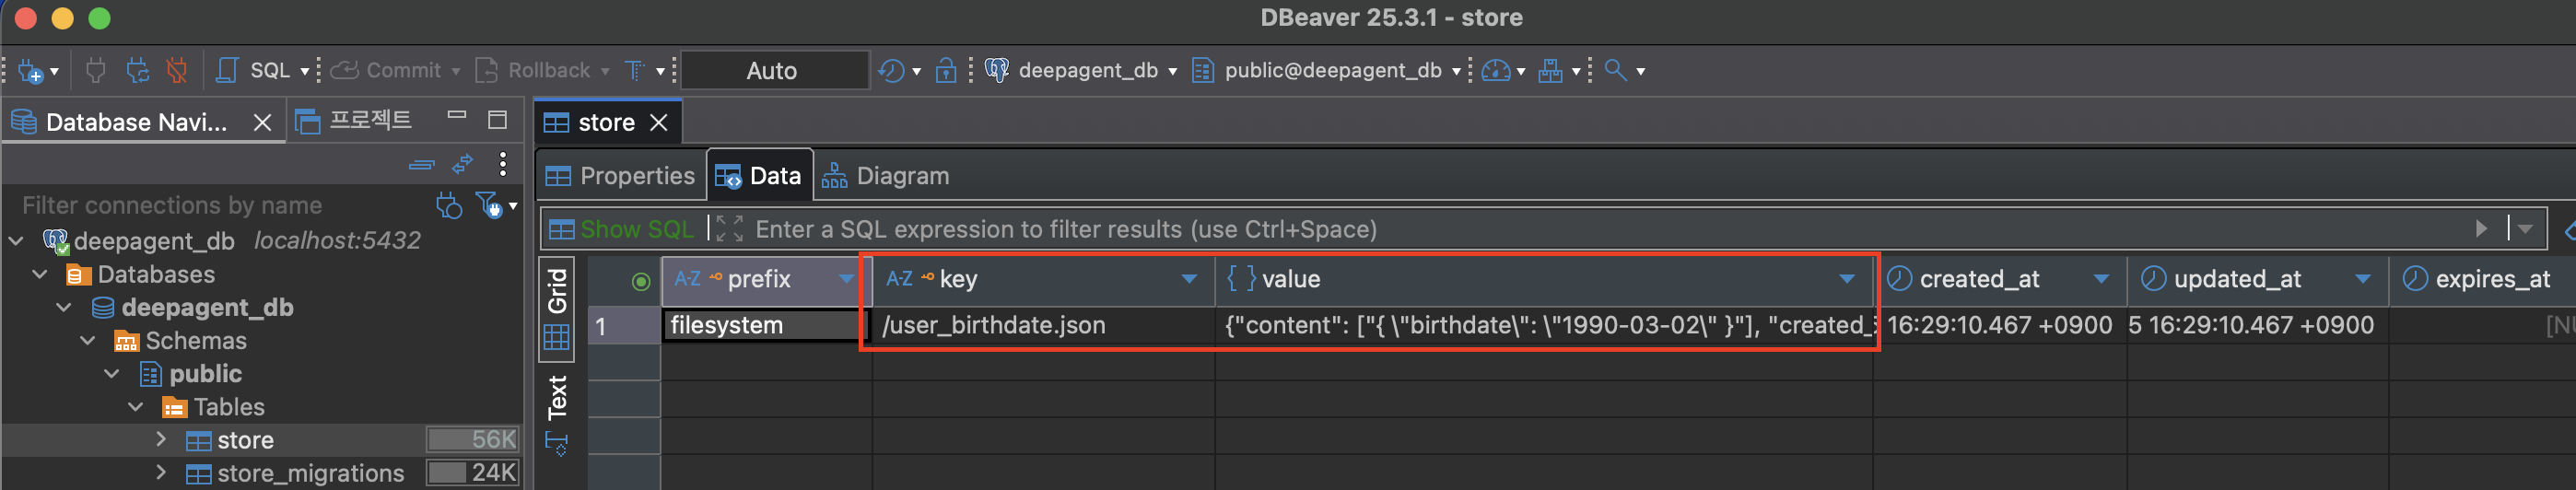

#### 문서·대용량 데이터 저장 테스트

에이전트는 `/files/` 경로에 저장하는 tool call을 해야 함.

1. “아래 텍스트를 파일로 저장해줘:
    - ‘주간 보고서: 매출 20% 상승, 신규 고객 35명.’”
    - “간단한 TODO 리스트를 파일로 만들어줘.”
2. “아래 JSON 데이터를 파일로 저장해줘.
    - { 'user': 'kwon', 'role': 'admin', 'active': true }”
4. “대화 내용을 텍스트 파일로 정리해서 저장해줘.”
5. “내가 설명한 알고리즘을 문서로 만들어서 저장해줘.”


In [12]:
import uuid
from langchain.messages import HumanMessage

config_2 = {"configurable": {"thread_id": str(uuid.uuid4())}}

response = agent.invoke({
    "messages": [HumanMessage(content="""
아래 텍스트를 파일로 저장해줘:
    - '주간 보고서: 매출 20% 상승, 신규 고객 35명.'
    - "간단한 TODO 리스트를 파일로 만들어줘."
""")]
}, config=config_2)

print(response["messages"][-1].content)


저장 완료했습니다.

- /files/weekly_report.txt — 주간 보고서: 매출 20% 상승, 신규 고객 35명.
- /files/simple_todo.txt — 간단한 TODO 리스트를 파일로 만들어줘.

다른 형식으로도 저장해 드리길 원하시면 말씀해 주세요.


> 생성된 파일 확인(매번 결과가 다를 수 있음)  

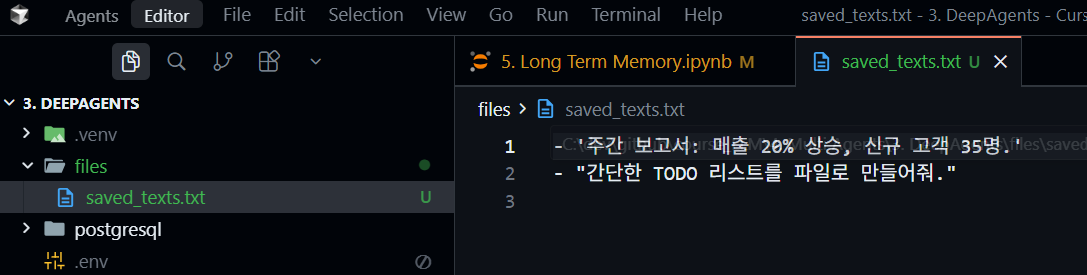

#### 임시 상태·저장 불필요 테스트 

저장이 필요 없으므로 state backend(기본) 만 사용해야 함.

1. “지금 내가 하고 싶은 말을 요약해줘.”
2. “아래 코드를 분석해줘.”
3. “10초 동안 카운트다운 해줘.”
4. “이번 질문에서는 저장하지 말고 단순히 계산만 해줘.”
5. “‘고양이’를 영어로 뭐라고 해?”


In [13]:
import uuid
from langchain.messages import HumanMessage

config_3 = {"configurable": {"thread_id": str(uuid.uuid4())}}

response = agent.invoke({
    "messages": [HumanMessage(content="'고양이'를 영어로 뭐라고 해?")]
}, config=config_3)

print(response["messages"][-1].content)


영어로는 "cat" 입니다. (복수형: "cats", 애칭으로는 "kitty"도 자주 씁니다.)


> Redis 확인 

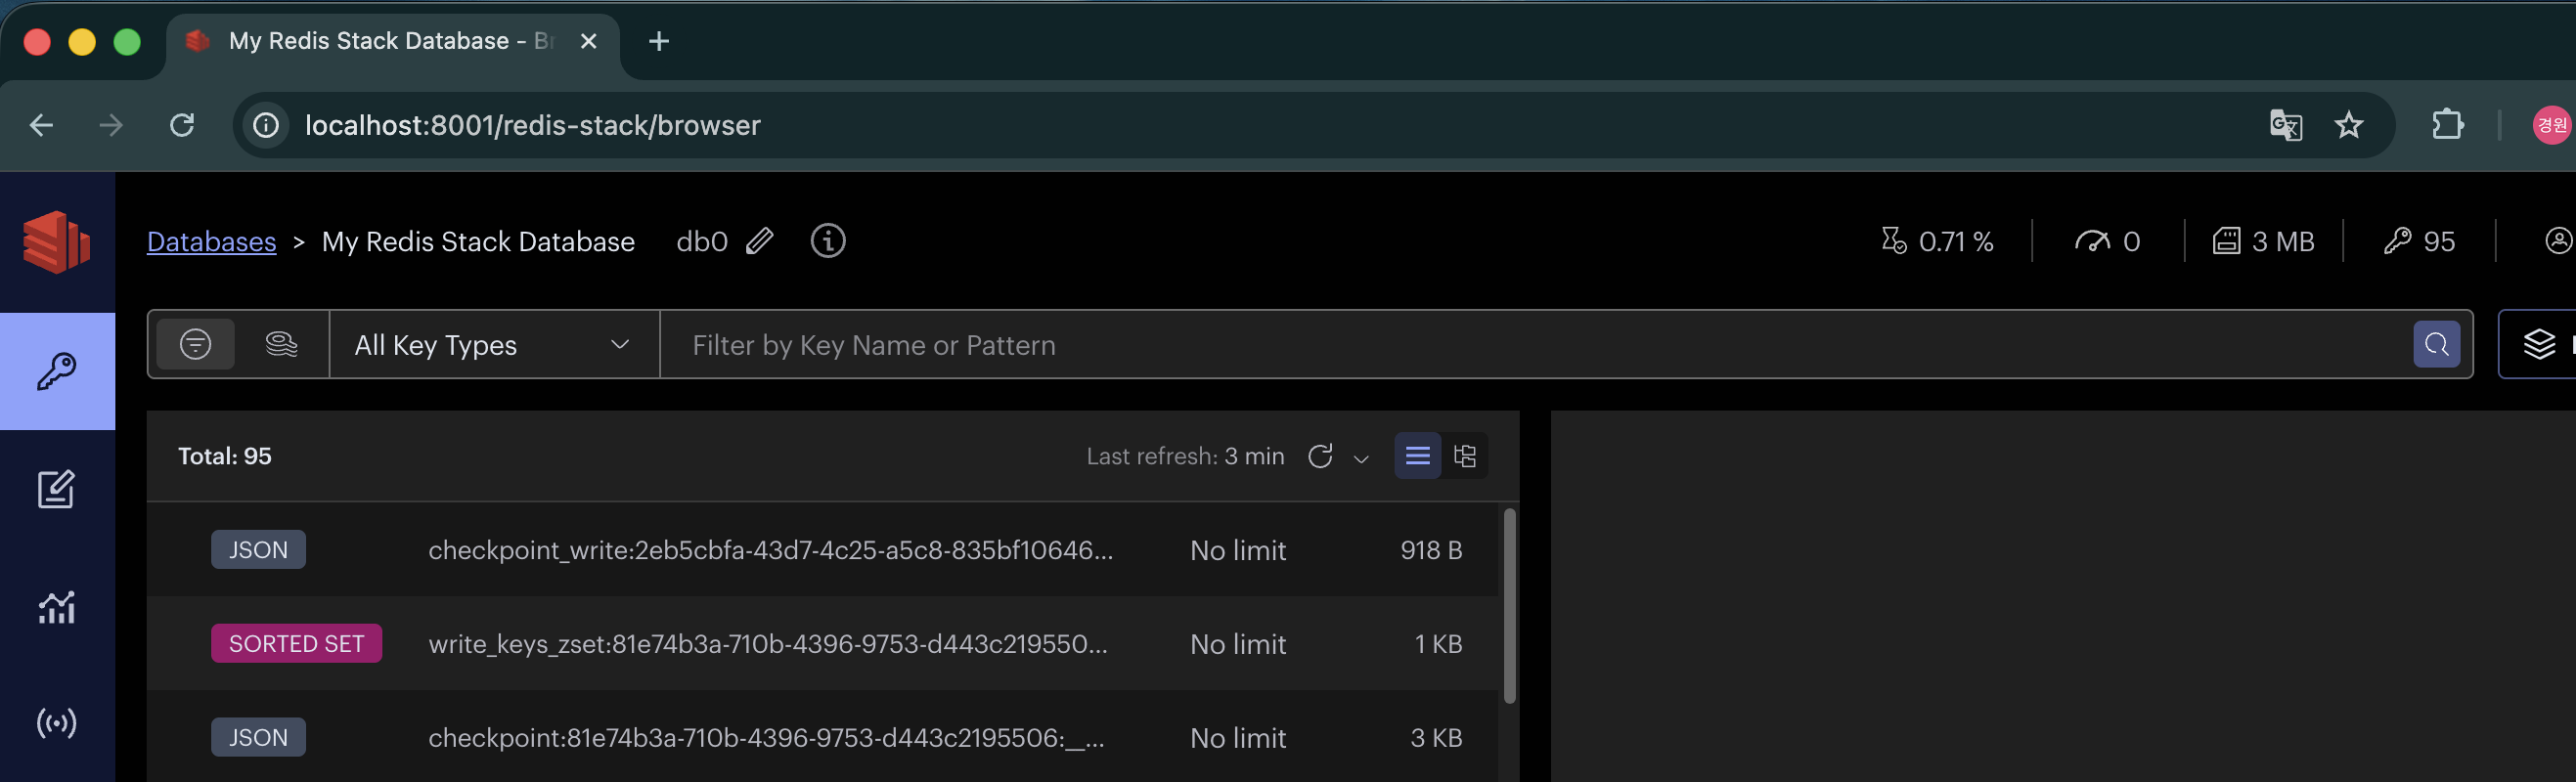

In [14]:
import redis
import json

# Redis 연결
r = redis.Redis(host='localhost', port=6379, db=0, decode_responses=True)

pattern = f'*{config_3["configurable"]["thread_id"]}*'
keys = r.keys(pattern)

print(f"총 {len(keys)}개의 키를 상세 조회합니다.\n")
print(f"✓ 키 목록 (처음 5개) 내용 확인")
for key in keys[:5]:
    key_type = r.type(key)
    print(f"   Key: {key}")
    print(f"   Type: {key_type}")

    try:
        # 1. ReJSON-RL 타입 처리 (RedisJSON)
        if key_type == 'ReJSON-RL':
            # .json() 인터페이스를 사용하여 JSON 데이터 조회
            data = r.json().get(key)
            print(f"   Value (JSON): {json.dumps(data, indent=2, ensure_ascii=False)}")

        # 2. zset 타입 처리 (Sorted Set)
        elif key_type == 'zset':
            # 점수(score)와 함께 데이터 가져오기
            data = r.zrange(key, 0, -1, withscores=True)
            print(f"   Value (ZSet): {data}")

        # 3. 그 외 기본 타입들
        elif key_type == 'string':
            print(f"   Value: {r.get(key)}")
        elif key_type == 'hash':
            print(f"   Value: {r.hgetall(key)}")
            
    except Exception as e:
        print(f"조회 중 오류 발생: {e}")

    print("-" * 80)

총 16개의 키를 상세 조회합니다.

✓ 키 목록 (처음 5개) 내용 확인
   Key: write_keys_zset:6535849f-95b8-414c-bc66-b7b53df82407:__empty__:1f0fbd43-42b0-6e20-bfff-19e2aef360da
   Type: zset
   Value (ZSet): [('checkpoint_write:6535849f-95b8-414c-bc66-b7b53df82407:__empty__:1f0fbd43-42b0-6e20-bfff-19e2aef360da:748a59c3-6da8-1210-aa66-4802c44c2479:0', 0.0), ('checkpoint_write:6535849f-95b8-414c-bc66-b7b53df82407:__empty__:1f0fbd43-42b0-6e20-bfff-19e2aef360da:748a59c3-6da8-1210-aa66-4802c44c2479:1', 1.0)]
--------------------------------------------------------------------------------
   Key: write_keys_zset:6535849f-95b8-414c-bc66-b7b53df82407:__empty__:1f0fbd43-42b2-6996-8000-b0b2abe7dd91
   Type: zset
   Value (ZSet): [('checkpoint_write:6535849f-95b8-414c-bc66-b7b53df82407:__empty__:1f0fbd43-42b2-6996-8000-b0b2abe7dd91:32a7d41b-b6b0-e538-7f54-91361b39ed17:0', 0.0), ('checkpoint_write:6535849f-95b8-414c-bc66-b7b53df82407:__empty__:1f0fbd43-42b2-6996-8000-b0b2abe7dd91:32a7d41b-b6b0-e538-7f54-91361b39ed17:1', 1.0

#### 복합 판단(저장 + 처리) 테스트

모델의 저장 판단 능력을 더 정교하게 테스트할 수 있는 고급 질문들입니다.(`/memories/` 와 `/files/` 를 둘 다 테스트 가능.)

In [16]:
# 복합 요청 실행
config_4 = {"configurable": {"thread_id": str(uuid.uuid4())}}
# 1. 입력 설정
inputs = {
    "messages": [
        {
            "role": "user", 
            "content": "내 이름은 '홍길동'이고 전공은 'AI 공학'이야. 이 정보를 내 프로필에 기억해줘. 그리고 [LangChain, DeepAgents] 기술 스택 요약본을 'tech_stack.txt' 파일로 저장해줘."
        }
    ]
}

print("--- DeepAgent 복합 작업 시작 ---\n")

# 2. 스트림 실행
for event in agent.stream(inputs, config=config_4):
    # event 자체가 dict가 아닐 경우 대비
    if not isinstance(event, dict):
        continue

    for node, value in event.items():
        # [수정 포인트] value가 None이거나 dict가 아닌 경우 건너뛰기
        if value is None or not isinstance(value, dict):
            continue
            
        messages = value.get("messages")
        if not messages or not isinstance(messages, list):
            continue
            
        last_msg = messages[-1]
        
        # A. Tool Call (기억/저장 로직) 확인
        if hasattr(last_msg, 'tool_calls') and last_msg.tool_calls:
            for tc in last_msg.tool_calls:
                args = tc.get('args', {})
                print(f"DEBUG - 전체 인자: {args}")
                path = tc['args'].get('file_path', '')
                
                if "/memories/" in path:
                    label = "StoreBackend (DB 기억)"
                elif "/files/" in path:
                    label = "FileSystem (파일 저장)"
                else:
                    label = "DefaultBackend (상태)"
                    
                print(f"[{label}] 호출됨")
                print(f"   - 경로: {path}")
                print(f"   - 내용: {tc['args']}")
        
        # B. 에이전트의 텍스트 응답 확인
        elif hasattr(last_msg, 'content') and last_msg.content:
            print(f"[Agent]: {last_msg.content}")

print("\n--- 작업 완료 ---")

--- DeepAgent 복합 작업 시작 ---

DEBUG - 전체 인자: {'file_path': '/memories/profile_홍길동.json', 'content': '{\\n  "name": "홍길동",\\n  "major": "AI 공학"\\n}'}
[StoreBackend (DB 기억)] 호출됨
   - 경로: /memories/profile_홍길동.json
   - 내용: {'file_path': '/memories/profile_홍길동.json', 'content': '{\\n  "name": "홍길동",\\n  "major": "AI 공학"\\n}'}
DEBUG - 전체 인자: {'file_path': '/files/tech_stack.txt', 'content': 'LangChain, DeepAgents 기술 스택 요약\\n\\nLangChain\\n- 목적: LLM과 도구를 연결해 체인/에이전트 구성\\n- 핵심 구성요소: LLM, PromptTemplate, Tools, Memory, Chain, Agent\\n- 사용 사례: RAG(검색 강화 생성), 자동화 파이프라인\\n\\nDeepAgents\\n- 목적: 멀티에이전트 시스템 설계 및 실행\\n- 핵심 구성요소: Agent, Planner, Orchestrator, Memory, Tools\\n- 특징: 에이전트 간 협업, 확장성 있는 워크플로우 구성, 분산 실행\\n'}
[FileSystem (파일 저장)] 호출됨
   - 경로: /files/tech_stack.txt
   - 내용: {'file_path': '/files/tech_stack.txt', 'content': 'LangChain, DeepAgents 기술 스택 요약\\n\\nLangChain\\n- 목적: LLM과 도구를 연결해 체인/에이전트 구성\\n- 핵심 구성요소: LLM, PromptTemplate, Tools, Memory, Chain, Agent\\n- 사용 사례: RAG(검색 강화 생성), 자동화 파이

> 생성된 파일 확인(매번 결과가 다를 수 있음)  

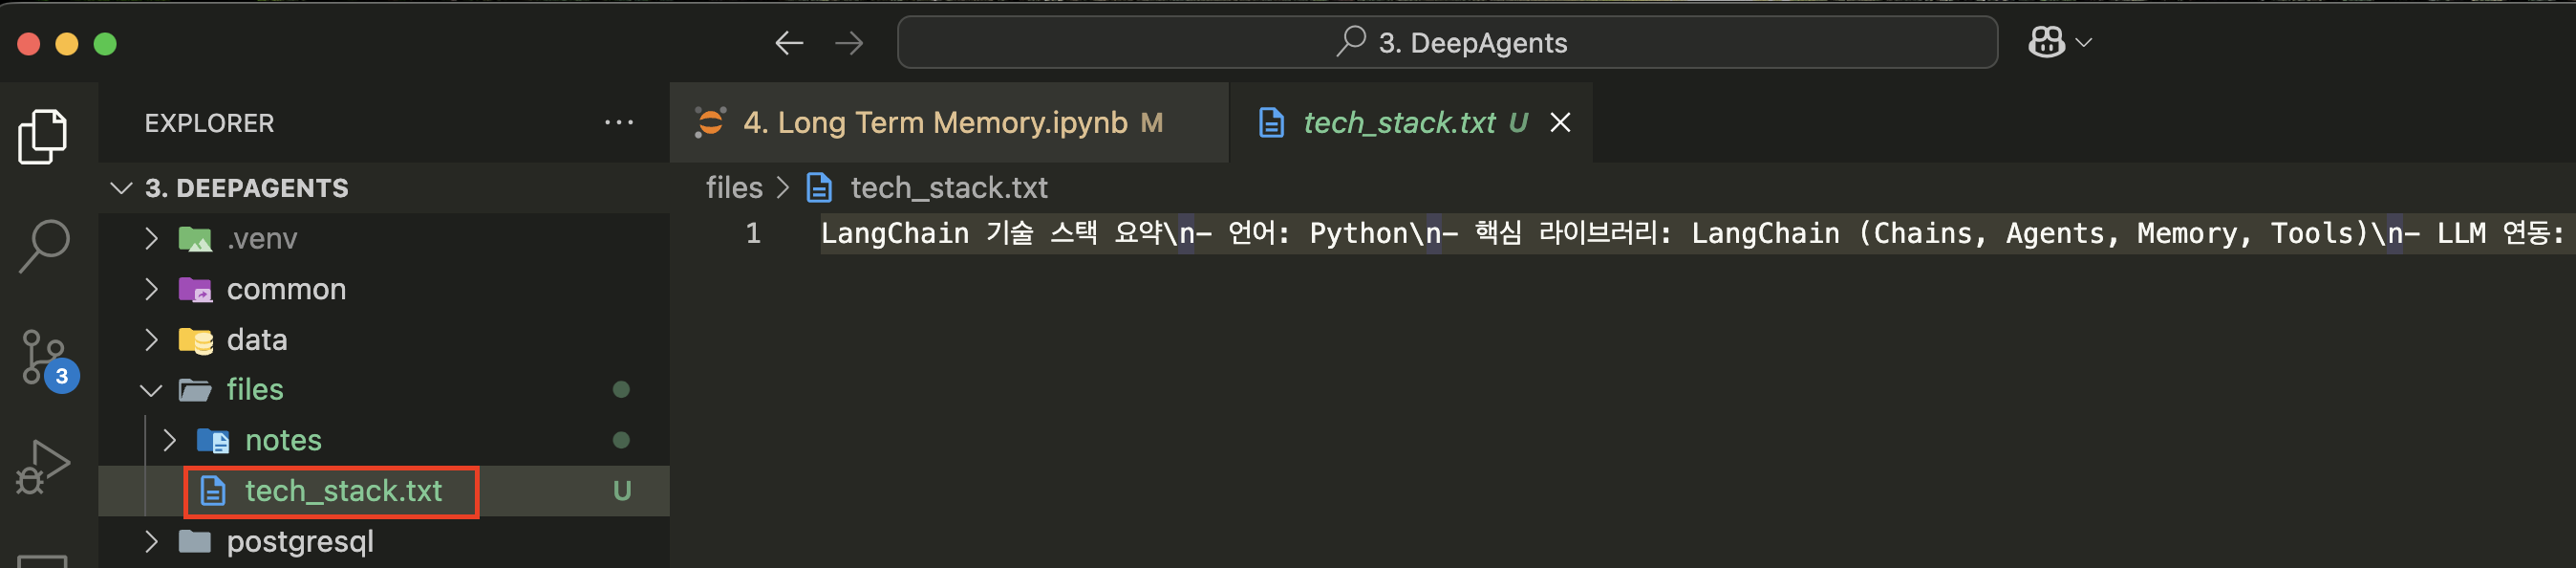

> PostgreSQL에서 데이터 확인(매번 결과가 다를 수 있음)  

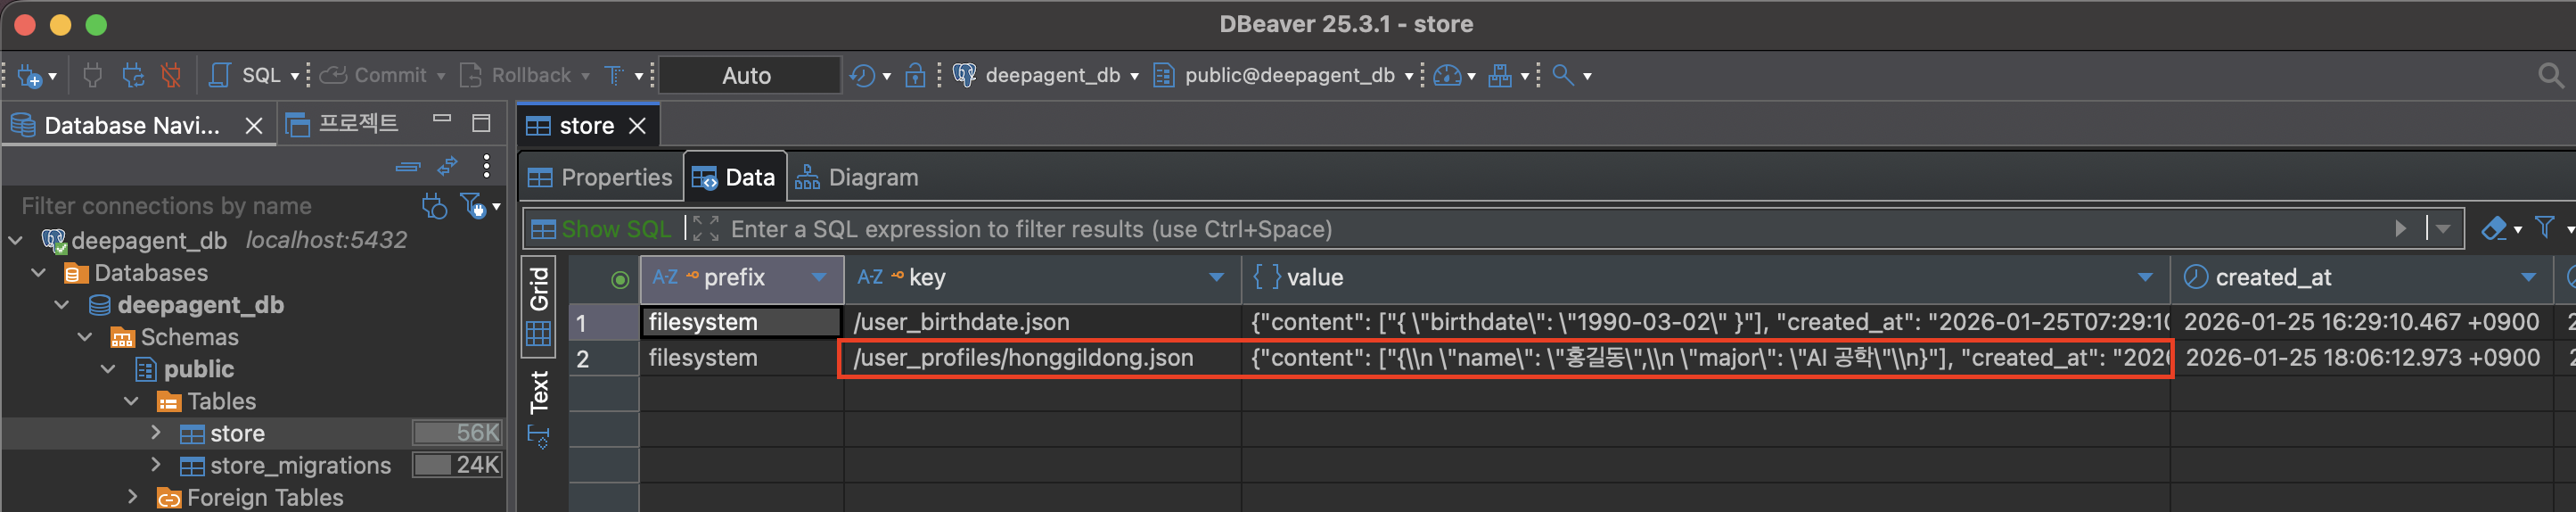

#### [Langsmith](https://smith.langchain.com/)

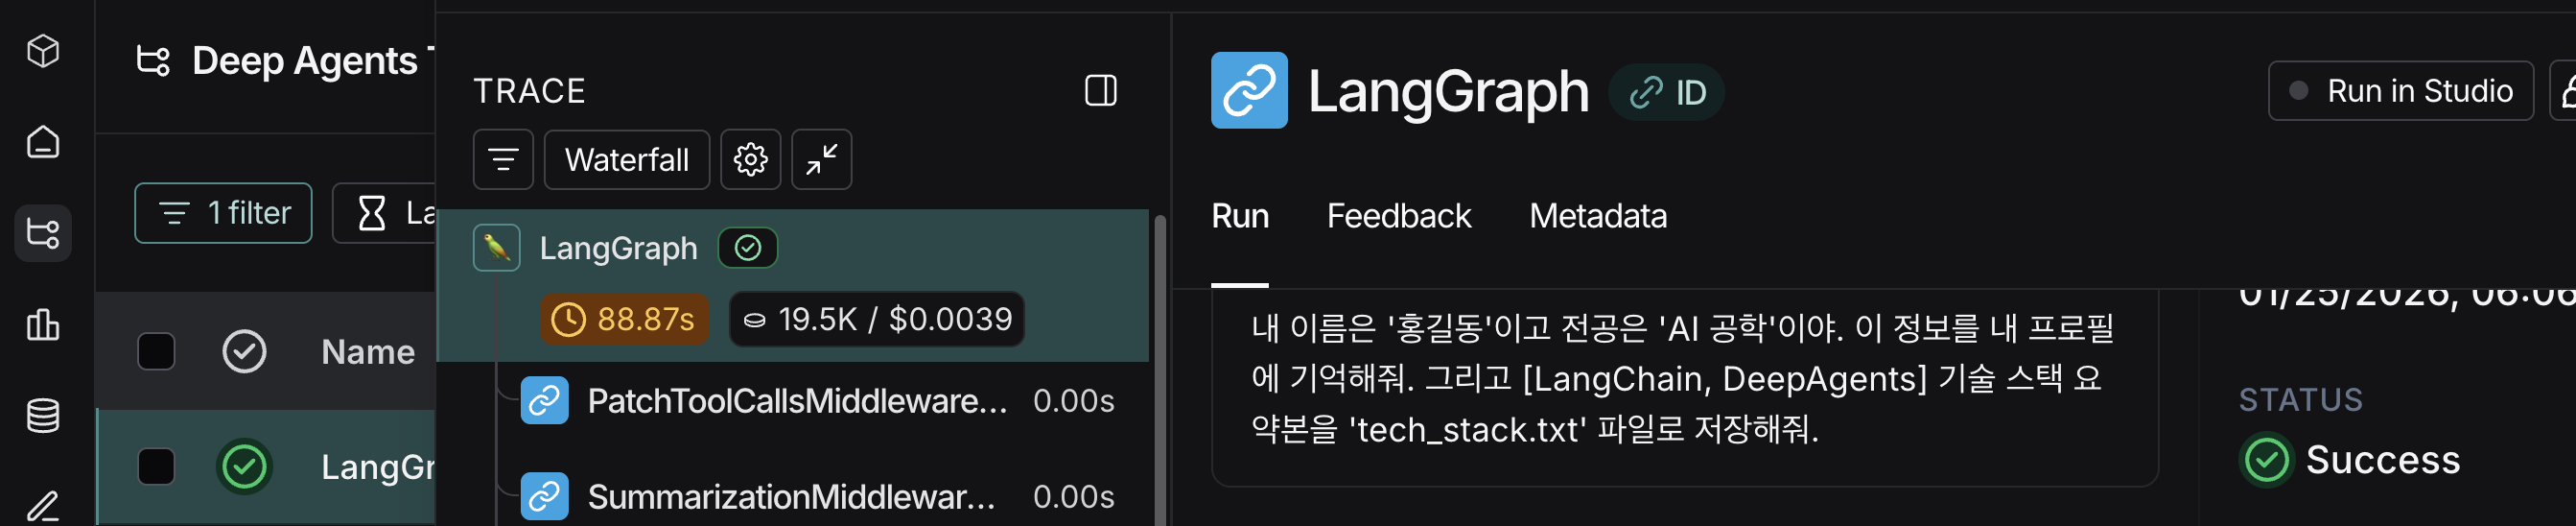